In [7]:
import tensorflow
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

In [8]:
IMG_SIZE=(256,256,3)
premodel=keras.applications.EfficientNetV2L(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=IMG_SIZE,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    include_preprocessing=True,
)

In [9]:
premodel.trainable=False


premodel.summary()


Model: "efficientnetv2-l"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 256, 256, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ rescaling_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 128, 128, 32)   │          9,216 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 128, 128, 32)   │            128 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 128, 128, 32)   │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_add (Add)         │ (None, 128, 128, 32)   │              0 │ block1a_project_activ… │
│                           │                        │                │ stem_activation[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_conv      │ (None, 128, 128, 32)   │          9,216 │ block1a_add[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_bn        │ (None, 128, 128, 32)   │            128 │ block1b_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_activati… │ (None, 128, 128, 32)   │              0 │ block1b_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_drop (Dropout)    │ (None, 128, 128, 32)   │              0 │ block1b_project_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_add (Add)         │ (None, 128, 128, 32)   │              0 │ block1b_drop[0][0],    │
│                           │                        │                │ block1a_add[0][0]      │
├──────────────────────

 Total params: 117,746,848 (449.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 117,746,848 (449.17 MB)

In [10]:
model= keras.Sequential()
model.add(premodel)
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(256,activation='relu'))
model.add(keras.layers.Dense(4,activation='softmax'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │      20,971,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,719,652 (529.17 MB)

 Trainable params: 20,972,804 (80.00 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [11]:
(train_ds),(test_ds)= keras.utils.image_dataset_from_directory(
    directory='drive/MyDrive/BrainMRIimage',
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='both',
    seed=42,
    batch_size=32,
    shuffle=True,

)



Found 3096 files belonging to 4 classes.
Using 2477 files for training.
Using 619 files for validation.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
class_names = train_ds.class_names
print(class_names)

['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


In [14]:
print(len(train_ds))
print(len(test_ds))

78
20


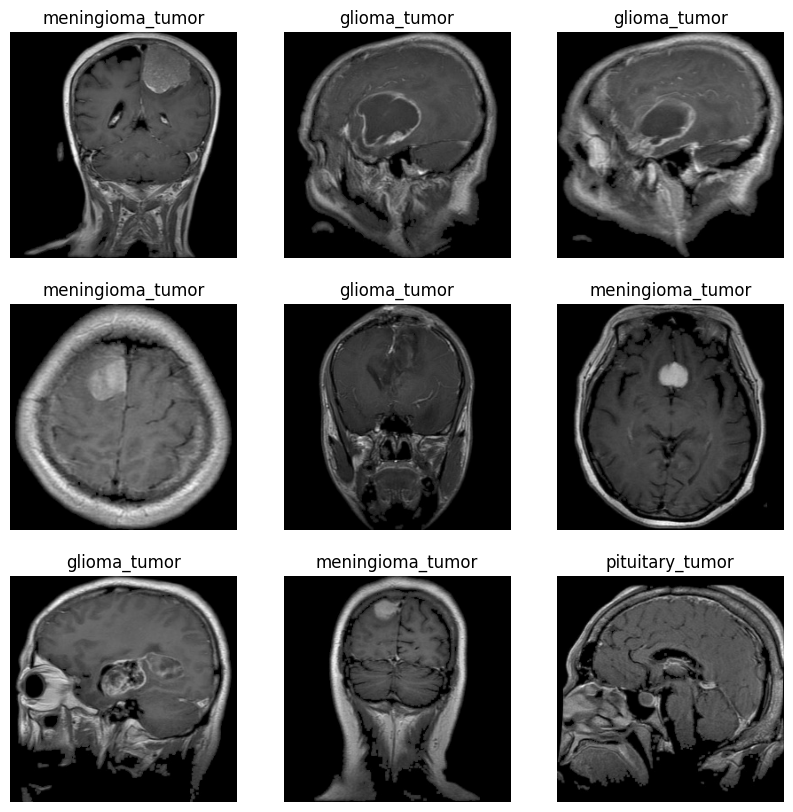

In [15]:


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [16]:
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy,
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │      20,971,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,719,652 (529.17 MB)

 Trainable params: 20,972,804 (80.00 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [17]:
history = model.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 809s 9s/step - accuracy: 0.5303 - loss: 7.7741 - val_accuracy: 0.8465 - val_loss: 0.4600
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 94s 464ms/step - accuracy: 0.8314 - loss: 0.4659 - val_accuracy: 0.7932 - val_loss: 0.5272
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 43s 493ms/step - accuracy: 0.8775 - loss: 0.3432 - val_accuracy: 0.8708 - val_loss: 0.3762
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 36s 455ms/step - accuracy: 0.8873 - loss: 0.2987 - val_accuracy: 0.8772 - val_loss: 0.3357
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 496ms/step - accuracy: 0.9242 - loss: 0.2149 - val_accuracy: 0.8611 - val_loss: 0.3954
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 454ms/step - accuracy: 0.9206 - loss: 0.2013 - val_accuracy: 0.8498 - val_loss: 0.4842
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 452ms/step - accuracy: 0.8952 - loss: 0.2967 - val_accuracy: 0.8885 - val_loss: 0.3201
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 454ms/step - accuracy: 0.9434 - loss: 0.1512 - val_accura

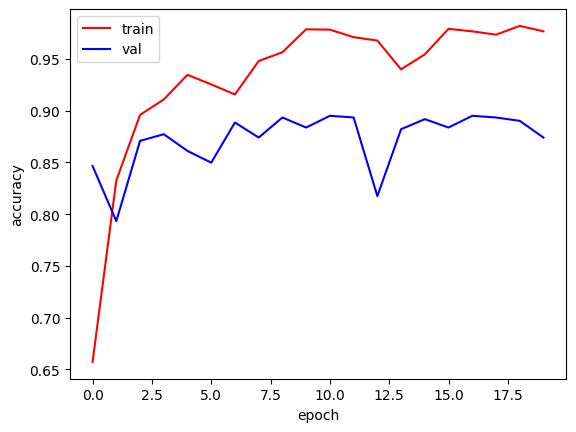

In [18]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

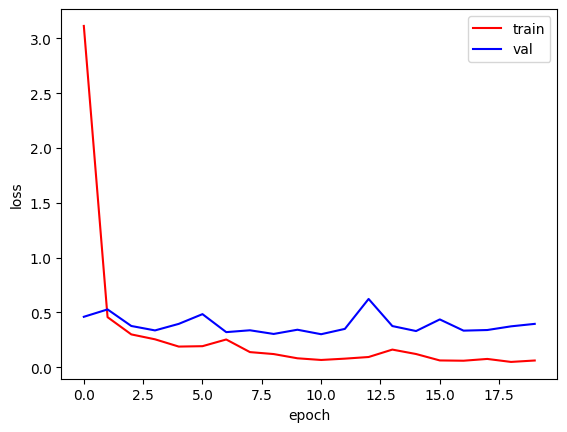

In [19]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)  # Get predicted labels for all samples
true_labels = []

# Extract true labels from the test dataset
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy}')
precision = precision_score(true_labels, predicted_labels, average='weighted')
print(f'Precision: {precision}')
recall= recall_score(true_labels, predicted_labels, average='weighted')
print(f'Recall: {recall}')
f1_score= f1_score(true_labels, predicted_labels, average='weighted')
print(f'F1 Score: {f1_score}')
confusion_matrix= confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{confusion_matrix}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step
Accuracy: 0.8739903069466882
Precision: 0.8802449029122359
Recall: 0.8739903069466882
F1 Score: 0.874452736653009
Confusion Matrix:
[[162   9   1   1]
 [ 35 154   3   3]
 [  3   2  68   0]
 [  4  16   1 157]]


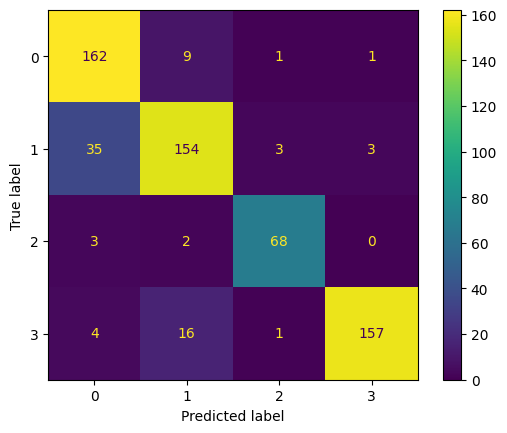

In [21]:
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [22]:
print(predicted_labels)

[0 0 1 1 0 1 1 0 3 3 2 3 2 1 0 0 3 0 3 3 3 0 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 0 0 2 3 0 1 1 0 0 0 0 3 1 3 3 1 1 2 1 1 0 3 0 0 3 0 0 3
 3 0 0 3 0 3 2 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 0 3 2 0 0 0 1 1 0 0
 3 0 1 3 0 2 0 3 1 0 3 0 0 1 1 3 3 3 1 3 3 0 0 2 0 0 3 1 1 0 1 2 3 3 1 1 1
 2 0 1 1 1 0 3 3 3 3 1 3 1 1 2 1 1 3 1 1 0 3 0 0 0 1 0 0 0 0 1 0 1 3 1 1 2
 1 3 0 0 1 2 1 1 0 0 2 3 3 1 0 0 0 0 1 0 0 0 1 0 1 3 3 3 1 0 1 3 3 3 3 2 1
 0 0 0 2 2 0 1 1 3 2 0 3 0 3 3 0 0 0 3 0 3 0 2 2 0 1 3 0 0 1 3 0 0 0 3 1 1
 0 2 1 2 2 0 0 2 1 3 0 1 0 0 1 0 0 3 1 1 3 3 3 1 3 2 1 0 3 0 0 3 3 0 1 3 0
 0 2 1 3 3 3 2 1 0 0 1 1 3 0 3 0 0 1 1 0 3 0 3 1 0 1 0 3 0 2 2 2 0 3 3 0 0
 1 1 0 0 0 0 2 2 0 1 3 1 2 3 0 3 3 2 0 3 0 3 1 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 1 0 1 2 1 3 0 3 0 1 1 0 1 0 0 1 0 0 3 0 0 0 0 1 0 3 1 1 0 3 1 3 1 1 3 1
 0 1 3 0 0 2 0 1 1 3 3 1 2 0 3 0 2 0 0 1 0 0 1 1 0 1 1 1 3 3 1 1 1 2 2 2 1
 1 1 3 3 0 1 0 3 1 3 1 1 2 1 1 3 1 0 1 3 3 3 1 2 0 1 0 3 0 0 3 2 1 0 1 3 0
 0 3 3 1 3 1 3 1 1 3 2 0 

In [23]:
print(true_labels)

[0 1 1 1 0 1 1 0 3 3 2 3 2 1 0 0 3 1 3 3 3 0 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 1 1 2 3 1 1 1 1 0 0 0 3 1 3 3 1 1 2 1 1 1 3 0 0 3 0 0 3
 3 0 0 3 0 3 2 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 2 3 2 0 0 0 1 1 0 0
 0 0 1 3 0 2 0 3 1 0 3 0 1 1 1 3 3 3 1 3 3 1 0 2 0 0 3 1 0 0 1 1 3 3 1 3 1
 2 0 3 1 1 0 3 3 3 3 1 3 1 1 2 1 1 3 1 1 0 3 0 1 0 1 0 0 0 1 1 0 0 3 1 1 2
 1 3 0 0 3 2 1 1 0 0 0 3 3 3 0 0 0 0 1 0 0 1 1 0 1 3 3 3 1 0 0 1 3 3 3 2 1
 0 0 0 2 2 0 1 1 3 2 1 3 0 3 3 0 0 0 3 0 3 1 2 2 0 1 3 0 0 1 3 0 1 0 3 3 1
 0 3 1 2 2 0 3 2 1 3 0 1 1 0 0 0 0 3 3 1 3 3 3 1 3 2 1 0 3 0 0 3 3 1 1 3 0
 0 2 1 3 3 3 2 1 1 0 1 3 3 0 3 1 1 1 3 1 3 1 3 1 0 1 1 3 0 2 2 2 0 3 3 0 0
 1 1 1 0 0 1 2 2 0 1 3 1 2 3 0 3 1 2 0 3 0 3 3 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 1 0 1 2 1 3 3 3 0 1 3 0 1 0 2 3 2 0 3 0 0 0 0 0 0 3 1 1 1 3 1 3 1 1 3 1
 0 1 3 0 0 2 0 1 1 3 3 1 2 1 3 1 2 0 0 1 0 0 1 1 0 1 1 1 3 3 1 1 1 2 1 2 1
 1 1 3 3 1 1 0 3 1 3 3 3 2 1 1 3 1 0 1 3 3 3 1 2 0 1 0 3 0 1 3 2 1 0 0 3 0
 0 3 3 1 3 1 3 1 1 3 2 3 

In [24]:
print(test_ds.class_names[0])

glioma_tumor


In [25]:
premodel.trainable=True

In [26]:
model= keras.Sequential()
model.add(premodel)
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(256,activation='relu'))
model.add(keras.layers.Dense(4,activation='softmax'))

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │      20,971,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,719,652 (529.17 MB)

 Trainable params: 138,207,076 (527.22 MB)

 Non-trainable params: 512,576 (1.96 MB)

In [27]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss=keras.losses.SparseCategoricalCrossentropy,
              metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │      20,971,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,719,652 (529.17 MB)

 Trainable params: 138,207,076 (527.22 MB)

 Non-trainable params: 512,576 (1.96 MB)

In [28]:
history1=model.fit(train_ds,epochs=20,validation_data=test_ds)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 737s 5s/step - accuracy: 0.6156 - loss: 1.0993 - val_accuracy: 0.9144 - val_loss: 0.2335
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9479 - loss: 0.1592 - val_accuracy: 0.9321 - val_loss: 0.2119
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9864 - loss: 0.0512 - val_accuracy: 0.9289 - val_loss: 0.3112
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9756 - loss: 0.0758 - val_accuracy: 0.9515 - val_loss: 0.2190
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9819 - loss: 0.0597 - val_accuracy: 0.9483 - val_loss: 0.1702
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9859 - loss: 0.0387 - val_accuracy: 0.9628 - val_loss: 0.1420
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9911 - loss: 0.0356 - val_accuracy: 0.9467 - val_loss: 0.2367
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9854 - loss: 0.0486 - val_accuracy: 0.9435 - v

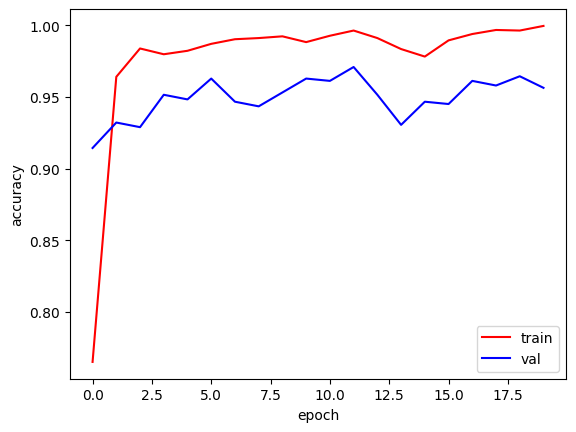

In [29]:
plt.plot(history1.history['accuracy'],color='red',label='train')
plt.plot(history1.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

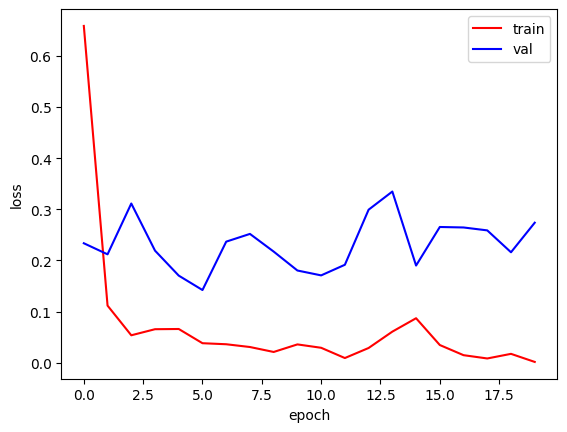

In [30]:
plt.plot(history1.history['loss'],color='red',label='train')
plt.plot(history1.history['val_loss'],color='blue',label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)  # Get predicted labels for all samples
true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy}')
precision = precision_score(true_labels, predicted_labels, average='weighted')
print(f'Precision: {precision}')
recall= recall_score(true_labels, predicted_labels, average='weighted')
print(f'Recall: {recall}')
f1_score= f1_score(true_labels, predicted_labels, average='weighted')
print(f'F1 Score: {f1_score}')
confusion_matrix= confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{confusion_matrix}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step
Accuracy: 0.9563812600969306
Precision: 0.9566849265260443
Recall: 0.9563812600969306
F1 Score: 0.956246700729639
Confusion Matrix:
[[162   4   6   1]
 [  7 182   0   6]
 [  0   1  72   0]
 [  0   2   0 176]]


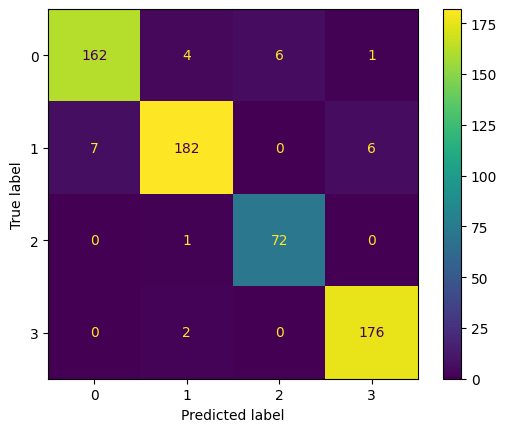

In [32]:
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()